# Gaussian (fBm) experiment — theta scaling analysis

This notebook loads a single `gaussian_experiment` run (MGD fit on fractional
Brownian motion / MRW increments — see `gaussian_experiment/run_SDE.py`) and
looks at the fitted Lagrange multipliers (`theta`), same idea as
`turbulence/turb_theta_scaling.ipynb` but for the much simpler Gaussian case.

Motivation, precisely stated: `Scattering_Fourth_Order_Mod2_Real_1d.forward()`
(`codes/potentials/potentials_1d.py`) computes the **raw** correlation
`E[ W_j(|Wx_s1|^2)(t) * W_j(|Wx_s2|^2)(t) ]` between the squared moduli of two
first-layer wavelet coefficients (fine scales `s1`, `s2`) — it does *not*
subtract a Gaussian baseline, so it is not a connected/cumulant statistic.

For jointly Gaussian `Wx` (guaranteed here: `x1` is fractional Gaussian
noise, a linear/stationary Gaussian process — see the data-generation cell
below), Isserlis'/Wick's theorem says this quantity is fully determined by
the *second*-order cross-correlation `Cov(Wx_s1, Wx_s2)`: it is exactly zero
when that cross-correlation is zero, and nonzero otherwise. Two things drive
that cross-correlation:
- the process's own power spectrum (flat/white for `H=0.5`, colored for
  `H != 0.5`);
- frequency-domain **overlap between the two wavelet filters themselves** —
  this codebase's filter bank (`codes/filters_bank.py`) is a redundant,
  continuous Morlet bank (not a critically-sampled orthogonal DWT), so
  immediately neighboring fine scales always overlap somewhat in frequency,
  for *any* input.

So the honest null-hypothesis prediction is **not** "flat zero everywhere":
it's "theta -> 0 for well-separated scale pairs `(s1, s2)`, with a small but
genuinely nonzero floor for near-diagonal pairs coming from filter-bank
leakage alone" (`indices_fourth_order_Q(..., offset=1)` already strips only
the exact self-pair `s1 == s2`, not a wider band around it — see
`codes/potentials/utils_potentials.py`). `H=0.5` (Brownian motion, i.e. white
noise increments) is the cleanest setting to check this, because it zeroes
out the spectrum's own contribution and isolates the filter-overlap floor;
moving to `H != 0.5` reintroduces real (but still purely second-order, not
non-Gaussian) cross-scale correlation from the fGn spectrum, which would
need to be compared against its analytic Gaussian value rather than literal
zero. This is the same statistic being computed on turbulence data, where
genuine non-Gaussian structure pushes it well past that Gaussian floor.

Steps in this first pass:
1. Load one experiment (data regeneration + saved SDE results + fitted potentials).
2. Plot the raw thetas, one panel per potential.
3. Apply the physical normalization (`codes/check_potentials.py`) and check
   the near-diagonal-vs-far-diagonal pattern described above.


In [1]:
import sys
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import torch
import matplotlib.pyplot as plt

# Notebook lives in gaussian_experiment/, mirroring run_SDE.py's own
# sys.path setup (see that file's module docstring for why this exact order
# matters: 'codes' and 'data' need to be importable both as packages and as
# bare top-level modules, since files under them cross-import each other
# both ways).
root = Path().resolve()
project_root = root.parent

for p in (root, project_root, project_root / 'codes', project_root / 'data'):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

from codes.sde_routines import *
from codes.utils import *
from codes.utils_experiment import *
from codes.check_moments import *
from codes.potentials_builder import *
from codes.filters_bank import *
from codes.check_potentials import *          # theta scaling / normalization toolkit
from codes.ortho_wavelet.ReadyToUseWavelets import *
from data.synthetic_data_generator import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('root:', root)


device: cuda
root: /lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/gaussian_experiment


## 1. Experiment parameters

Fill these in to match the seed-sweep runs you want to inspect (same fields
`build_config_name` hashes into the config string — see
`codes/utils_experiment.py`). `SEED_RANGE` sets which `--seed` values to
average over; `label` stays `None` and `timestamp` stays empty since the
seed-sweep runs on disk weren't launched with `--label`.


In [6]:
J = 5
Q = 1
M = 32
hurst = 0.5            # 0.5 = standard Brownian motion; fBm increments are Gaussian either way
intermittency = 0.0    # 0.0 -> pure fBm (Gaussian increments); >0 adds MRW multifractal modulation
sigma = 1.0
nt = 1000
n1 = 15000
lam = 1e-06            # the seed-sweep runs used lam=2e-08 -- NOT the 5e-6 single-run example this notebook started from
regularization = 1e-5
n_subsample = 10

terms=[
    #'Scattering_First_Order', 
    'Scattering_Second_Order',
    'Scattering_Fourth_Order_Mod2_Real_Q1',
    'Scattering_Fourth_Order_Mod2_Imag_Q1',
]

SEED_RANGE = range(300, 399)   # seeds 300..350 inclusive -- the 51-run sweep on disk

args = SimpleNamespace(
    J=J, Q=Q, hurst=hurst, intermittency=intermittency,
    sigma=sigma, nt=nt, n1=n1, lam=lam,
    regularization=regularization, n_subsample=n_subsample,
    terms=terms, seed=SEED_RANGE.start,   # placeholder -- the loader below overrides seed per iteration
    interpolant='Cos', batch_size=None,
    label="gaussian_d32",       # the seed-sweep runs were NOT launched with --label (unlike the earlier debug runs)
    timestamp='',     # left empty -> resolver finds the latest matching run per seed
    force_rerun=False,
)

REAL_KEY = 'Scattering_Fourth_Order_Mod2_Real_Q1'
IMAG_KEY = 'Scattering_Fourth_Order_Mod2_Imag_Q1'
COMPLEX_NAME = 'Scattering_Fourth_Order_Mod2_Q1'


## 2. Define potentials from terms

Build the nominal potentials from `terms` (deterministic given `J`/`Q` —
not seed-dependent, since none of these four terms prune per-seed the way
the turbulence experiment's `Scalar_GGD_KRegion`-based potentials do). This
gives one fixed column layout (`theta_column_map`) shared by every seed in
the sweep, so it only needs to be built once, before the seed loop.


In [7]:
filters, filters_Phi = return_Filters(M, args.J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, args.J, args.Q, device=device)

potentials = get_1d_potentials(
    terms, args.J, filters, args.Q,
    scalar_param=None, parallel=False,
    filters_Q=filters_Q, filters_Phi=filters_Phi,
)

total_dim = sum(p.num_coefficients for p in potentials.values())
print(f"sum(num_coefficients) = {total_dim}")


sum(num_coefficients) = 36


## 3. Load the seed sweep

For each seed in `SEED_RANGE`: regenerate that seed's own `x1` (needed for
`m_k`/`std_k` below — `x1` is never saved to disk, `run_SDE.py`
regenerates it from the RNG seed every time), resolve + load its saved
`theta_t` **and** `Theta_reg` (the regularised trajectory, also returned by
`load_results`/`try_load_experiment` — every analysis from here on runs on
*both*), and evaluate `compute_mk`/`compute_stdk` on that seed's `x1`
against the shared `potentials` from section 2. Stacks everything into
`(n_seeds, n_features)` arrays — `theta_all`, `theta_reg_all`, `mk_all`,
`stdk_all` — for the mean +/- std analyses below. A seed is only kept if
*both* `theta_t` and `Theta_reg` loaded, so `theta_all`/`theta_reg_all`
stay aligned row-for-row (same seed at the same index in both). Reports how
many of `SEED_RANGE` actually resolved instead of failing silently.


In [8]:
theta_all_list, theta_reg_all_list, mk_all_list, stdk_all_list = [], [], [], []
seeds_loaded, seeds_missing, seeds_missing_reg = [], [], []

for seed in SEED_RANGE:
    args_seed = SimpleNamespace(**{**vars(args), 'seed': seed})
    config_prefix = build_config_name(args_seed, M, coarse_grained=False, include_timestamp=False)
    resolved_config = resolve_config_for_loading(root, config_prefix)
    if resolved_config is None:
        seeds_missing.append(seed)
        continue

    loaded = try_load_experiment(root, resolved_config, device)
    if loaded is None or not loaded.get('loaded', False):
        seeds_missing.append(seed)
        continue

    theta_t_seed = loaded['theta_t']
    theta_reg_seed = loaded['Theta_reg']
    if theta_reg_seed is None:
        # theta_t loaded fine but no regularised trajectory was saved for this
        # seed -- drop it entirely rather than let theta_all/theta_reg_all
        # go out of sync (every downstream cell assumes row i is the same
        # seed in both arrays).
        seeds_missing_reg.append(seed)
        continue

    # Only regenerate x1 (the expensive part) once we know this seed's run
    # actually resolved and loaded -- no point synthesizing data for seeds
    # that have nothing on disk.
    torch.manual_seed(seed)
    np.random.seed(seed)
    raw = load_synthetic_data('mrw', args.n1, M + 1, lam=args.intermittency, H=args.hurst).to(device)
    x1_seed = normalize(raw.diff(dim=-1)).to(device)

    theta_final_seed = theta_t_seed[-1] if torch.is_tensor(theta_t_seed) else torch.as_tensor(theta_t_seed[-1])
    theta_reg_final_seed = theta_reg_seed[-1] if torch.is_tensor(theta_reg_seed) else torch.as_tensor(theta_reg_seed[-1])
    theta_all_list.append(theta_final_seed)
    theta_reg_all_list.append(theta_reg_final_seed)
    mk_all_list.append(compute_mk(potentials, x1_seed))
    stdk_all_list.append(compute_stdk(potentials, x1_seed))
    seeds_loaded.append(seed)
    x1_last = x1_seed   # kept only as a harmless placeholder -- build_theta_dataframe's signature
                         # requires an x1 arg, but section 6 below only ever uses normalize_by in
                         # {'raw', 'm_k', 'std_k'}, none of which actually read it

if not theta_all_list:
    example_prefix = build_config_name(
        SimpleNamespace(**{**vars(args), 'seed': f'<{SEED_RANGE.start}..{SEED_RANGE.stop - 1}>'}),
        M, coarse_grained=False, include_timestamp=False,
    )
    raise FileNotFoundError(
        f"No seeds matched under {root / 'saved_results'} for pattern like "
        f"'{example_prefix}'. Check lam/nt/label in section 1 against what's "
    )

theta_all = torch.stack(theta_all_list)          # (n_seeds, n_features) -- theta_t (MGD, unregularised)
theta_reg_all = torch.stack(theta_reg_all_list)  # (n_seeds, n_features) -- Theta_reg (regularised)
mk_all = np.stack(mk_all_list)
stdk_all = np.stack(stdk_all_list)

# Every plot/table from here on runs on BOTH of these, clearly labeled by key.
SOURCES = {'theta (MGD)': theta_all, 'theta_reg': theta_reg_all}

print(f"Loaded {len(seeds_loaded)}/{len(list(SEED_RANGE))} seeds -> theta_all/theta_reg_all shape {tuple(theta_all.shape)}")
if seeds_missing:
    print(f"Missing/unloadable seeds ({len(seeds_missing)}): {seeds_missing}")
if seeds_missing_reg:
    print(f"Seeds with theta_t but no Theta_reg, dropped so both arrays stay aligned "
          f"({len(seeds_missing_reg)}): {seeds_missing_reg}")

assert theta_all.shape == theta_reg_all.shape, "theta_all/theta_reg_all should be aligned 1:1 by construction"
assert theta_all.shape[-1] == sum(p.num_coefficients for p in potentials.values()), (
    "theta_all's feature count doesn't match `potentials` from section 2 -- "
    "check J/Q/terms match the swept runs."
)

Model MRW: generating data ...


100%|██████████| 235/235 [00:00<00:00, 770.20it/s]


Finished.
Model MRW: generating data ...


100%|██████████| 235/235 [00:00<00:00, 563.62it/s]


Finished.
Model MRW: generating data ...


...

Finished.
Model MRW: generating data ...


100%|██████████| 235/235 [00:00<00:00, 824.04it/s]


Finished.
Model MRW: generating data ...


100%|██████████| 235/235 [00:00<00:00, 824.96it/s]


Finished.
Loaded 99/99 seeds -> theta_all/theta_reg_all shape (99, 36)


## Check that the regularization does not introduce bias 

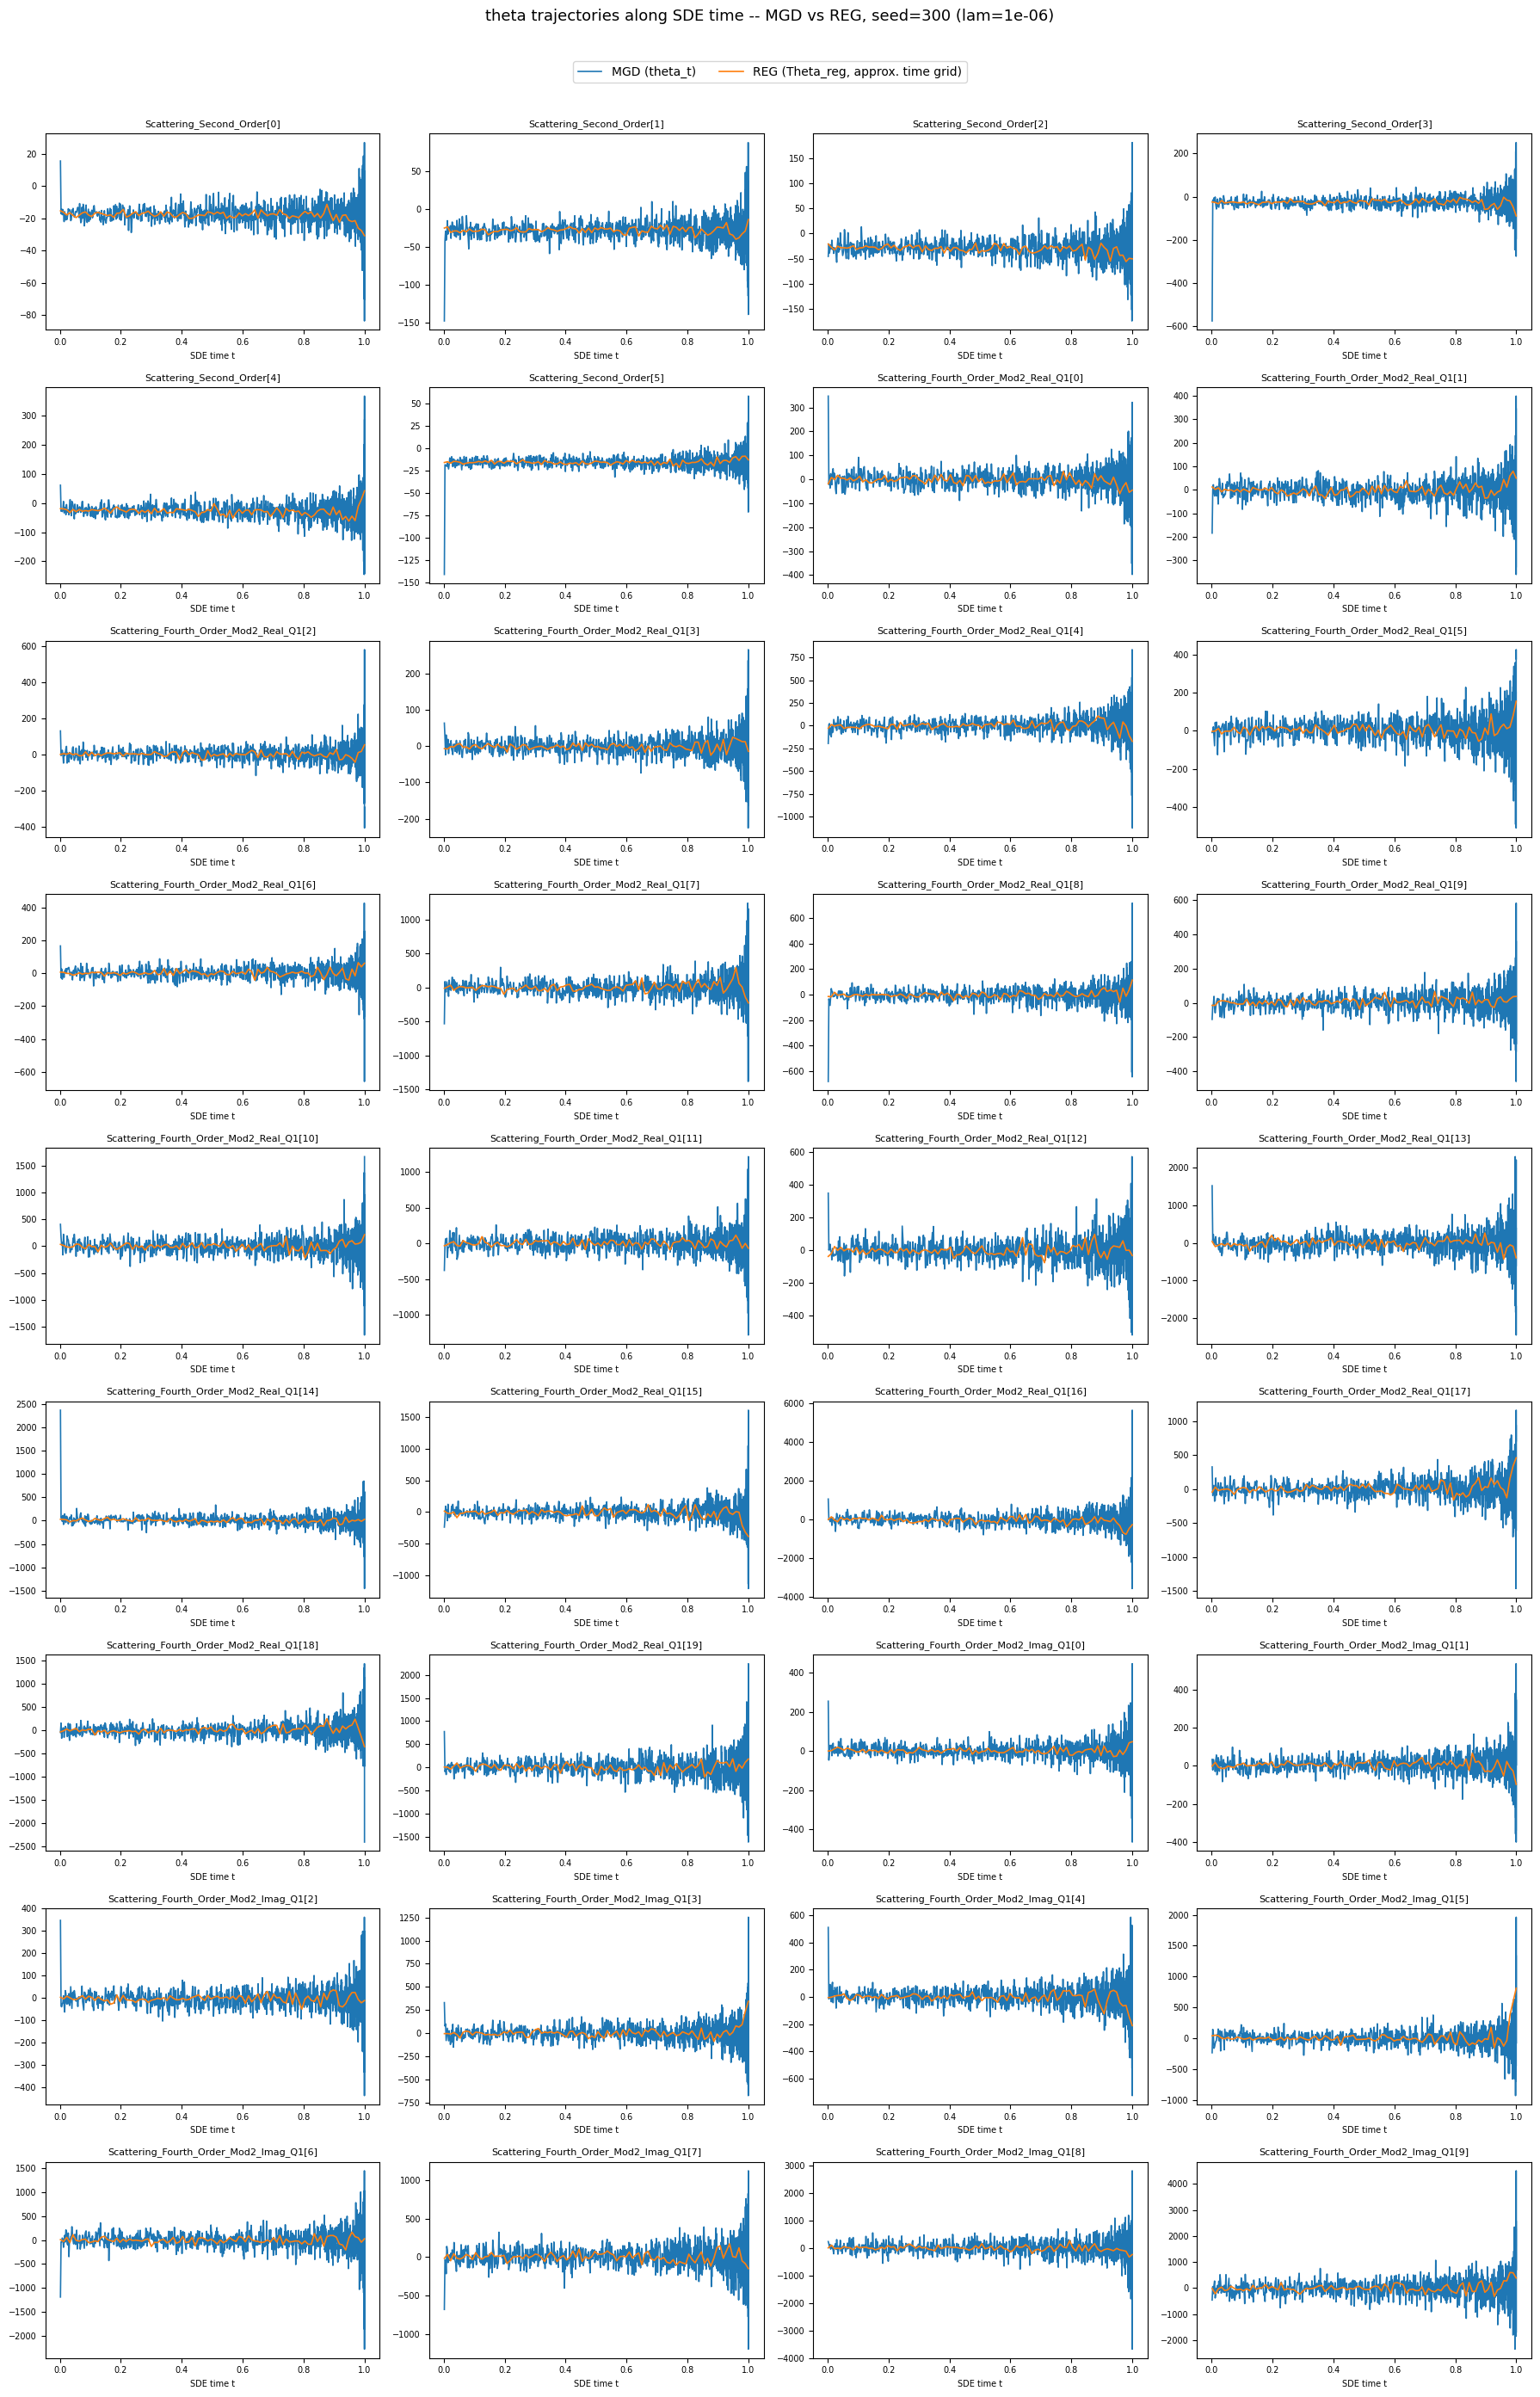

In [11]:
seed = 300 # pick the seed you want to inspect

args_seed = SimpleNamespace(**{**vars(args), 'seed': seed})
config_prefix = build_config_name(args_seed, M, coarse_grained=False, include_timestamp=False)
resolved_config = resolve_config_for_loading(root, config_prefix)
if resolved_config is None:
    raise FileNotFoundError(f"No saved run matches '{config_prefix}' for seed {seed}.")

loaded = try_load_experiment(root, resolved_config, device)
if loaded is None or not loaded.get('loaded', False):
    raise FileNotFoundError(f"Found '{resolved_config}' but failed to load it.")

theta_t_seed = loaded['theta_t']
theta_reg_seed = loaded['Theta_reg']
if theta_reg_seed is None:
    raise ValueError(f"Seed {seed}'s run has theta_t but no Theta_reg -- was it saved with regularization on?")

t_np = loaded['t'].cpu().numpy() if torch.is_tensor(loaded['t']) else np.asarray(loaded['t'])
theta_np = theta_t_seed.detach().cpu().numpy() if torch.is_tensor(theta_t_seed) else np.asarray(theta_t_seed)
theta_reg_np = theta_reg_seed.detach().cpu().numpy() if torch.is_tensor(theta_reg_seed) else np.asarray(theta_reg_seed)

n_t = theta_np.shape[0]
t_np = t_np[-n_t:]   # align t's tail with theta_t/Theta_reg (from the earlier length-mismatch fix)

if theta_reg_np.shape[0] != t_np.shape[0]:
    # Theta_reg lives on a coarser, NON-UNIFORM grid (n_subsample blocking + _cut_close_time_nodes
    # pruning near t_final, see forward_regularised) that is never saved to disk -- save_results_theta_reg
    # only stores the fine-grid `t`. This is an approximation for plotting only (evenly spaced between
    # the same endpoints) -- don't read exact x-positions off it, only the overall shape/trend.
    t_reg_np = np.linspace(t_np[0], t_np[-1], theta_reg_np.shape[0])
else:
    t_reg_np = t_np
n_features = theta_np.shape[-1]
col_map = theta_column_map(potentials, n_features, verbose=False)
coef_labels = [f'coef {k}' for k in range(n_features)]
for name, (start, dim) in col_map.items():
    for j in range(dim):
        coef_labels[start + j] = f"{name}[{j}]"

ncols = 4
nrows = math.ceil(n_features / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3 * nrows), squeeze=False)
axes = axes.flatten()

for k in range(n_features):
    ax = axes[k]
    ax.plot(t_np,     theta_np[:, k],     color='tab:blue',   lw=1.2,          label='MGD (theta_t)')
    ax.plot(t_reg_np, theta_reg_np[:, k], color='tab:orange', lw=1.2, label='REG (Theta_reg, approx. time grid)')
    ax.set_title(coef_labels[k], fontsize=8)
    ax.set_xlabel('SDE time t', fontsize=7)
    ax.tick_params(labelsize=7)

for k in range(n_features, len(axes)):
    axes[k].axis('off')

handles, labels_ = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_, loc='upper center', ncol=2, fontsize=10, bbox_to_anchor=(0.5, 1.01))
fig.suptitle(f'theta trajectories along SDE time -- MGD vs REG, seed={seed} (lam={args.lam})', fontsize=13, y=1.03)
fig.tight_layout()
%matplotlib inline
plt.show()

## 4. Variance comparison: theta vs theta_reg

Before looking at individual potentials, a per-coefficient sanity check
across the *whole* feature vector: variance, relative variance
(`Var / mean^2`), coefficient of variation (`std / |mean|`), and
signal-to-noise (`|mean| / std`) across the `len(seeds_loaded)` seeds, for
both `theta` (MGD, unregularised) and `theta_reg` (regularised) — the same
diagnostic `turb_theta_scaling.ipynb` runs for `Theta_reg`/`Theta_MGD`.
Potential boundaries (from `theta_column_map`, colored automatically —
no hand-maintained color dict to keep in sync with `terms`) are shaded for
reference so a spike can be attributed to a specific potential.


In [12]:
from IPython.display import Markdown  # safe if already imported elsewhere

eps = 1e-12

# k indexes a single coefficient; the sum/statistics below run over the N seeds
STAT_FORMULAE = {
    'mean':    r"$\mu_k = \dfrac{1}{N}\sum_{i=1}^N \theta_k^{(i)}$",
    'std':     r"$\sigma_k = \sqrt{\dfrac{1}{N-1}\sum_{i=1}^N \left(\theta_k^{(i)} - \mu_k\right)^2}$",
    'var':     r"$\mathrm{Var}_k = \sigma_k^2$",
    'cv':      r"$\mathrm{CV}_k = \dfrac{\sigma_k}{|\mu_k| + \epsilon}$",
    'rel\_var':r"$\mathrm{RelVar}_k = \dfrac{\mathrm{Var}_k}{\mu_k^2 + \epsilon} = \mathrm{CV}_k^2$",
    'snr':     r"$\mathrm{SNR}_k = \dfrac{|\mu_k|}{\sigma_k + \epsilon}$",
}

def compute_stats(theta_arr):
    X = theta_arr.detach().cpu().numpy() if torch.is_tensor(theta_arr) else np.asarray(theta_arr)
    mean = X.mean(axis=0)
    std = X.std(axis=0, ddof=1)   # ddof=1 -- sample std across seeds
    var = std ** 2
    cv = std / (np.abs(mean) + eps)
    rel_var = var / (mean ** 2 + eps)
    snr = np.abs(mean) / (std + eps)
    return dict(mean=mean, std=std, var=var, cv=cv, rel_var=rel_var, snr=snr)

stats_by_source = {name: compute_stats(arr) for name, arr in SOURCES.items()}

# --- formulae, printed once so the table below is self-explanatory ---
display(Markdown(
    f"**Per-coefficient statistics across seeds** "
    f"($k$ = coefficient index, $N$ = {len(seeds_loaded)} seeds, $\\epsilon$ = {eps:g}):\n\n"
    + "\n".join(f"- **{key}**: {formula}" for key, formula in STAT_FORMULAE.items())
    + "\n\nThe summary table aggregates each per-coefficient stat **across coefficients** "
      "(mean / median over $k$), one row per source (MGD vs REG)."
))

# --- summary table: one row per source, columns = aggregated stats ---
summary_rows = {}
for name, stats in stats_by_source.items():
    summary_rows[name] = {
        'mean variance':     stats['var'].mean(),
        'median variance':   np.median(stats['var']),
        'mean rel_var':      stats['rel_var'].mean(),
        'mean CV':           stats['cv'].mean(),
        'mean SNR':          stats['snr'].mean(),
    }
summary_df = pd.DataFrame(summary_rows).T   # transpose -> one row per source (MGD/REG), not per stat
display(summary_df)

**Per-coefficient statistics across seeds** ($k$ = coefficient index, $N$ = 99 seeds, $\epsilon$ = 1e-12):

- **mean**: $\mu_k = \dfrac{1}{N}\sum_{i=1}^N \theta_k^{(i)}$
- **std**: $\sigma_k = \sqrt{\dfrac{1}{N-1}\sum_{i=1}^N \left(\theta_k^{(i)} - \mu_k\right)^2}$
- **var**: $\mathrm{Var}_k = \sigma_k^2$
- **cv**: $\mathrm{CV}_k = \dfrac{\sigma_k}{|\mu_k| + \epsilon}$
- **rel\_var**: $\mathrm{RelVar}_k = \dfrac{\mathrm{Var}_k}{\mu_k^2 + \epsilon} = \mathrm{CV}_k^2$
- **snr**: $\mathrm{SNR}_k = \dfrac{|\mu_k|}{\sigma_k + \epsilon}$

The summary table aggregates each per-coefficient stat **across coefficients** (mean / median over $k$), one row per source (MGD vs REG).

,mean variance,median variance,mean rel_var,mean CV,mean SNR
theta (MGD),962545.875000,317562.375,2023.512573,28.093384,0.118273
theta_reg,114140.914062,35343.625,27548.261719,64.564194,0.219223


## 5. Raw thetas — theta vs theta_reg, mean +/- std across seeds

Every potential is plotted once, with **both** `theta` (MGD) and
`theta_reg` overlaid in the same figure (distinct colors, legend) rather
than as two separately-titled figures that would look identical at a
glance — that's the "clearly state which is which" requirement from a
comparison standpoint, not just a label. `plot_linear_potential_compare`
handles the two real-valued potentials; `plot_complex_potential_compare`
handles the `Real_Q1`/`Imag_Q1` pair, aligning `Imag_Q1`'s (typically
shorter, pruned) index layout onto `Real_Q1`'s via
`expand_imag_to_real_indices` — same convention `build_all_averaged_vectors`
uses — before combining, for each source separately.


In [13]:
%matplotlib inline

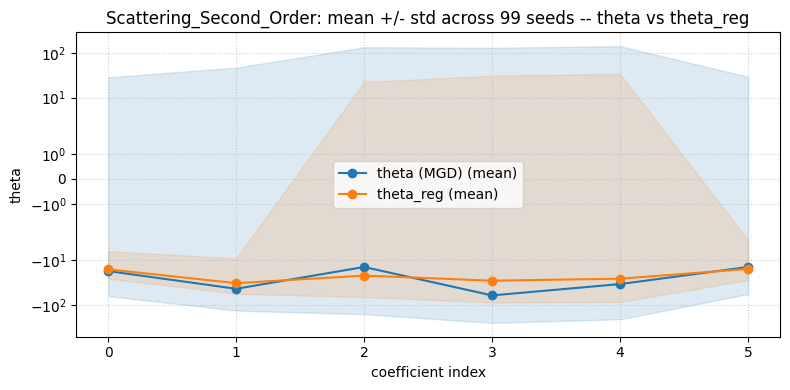

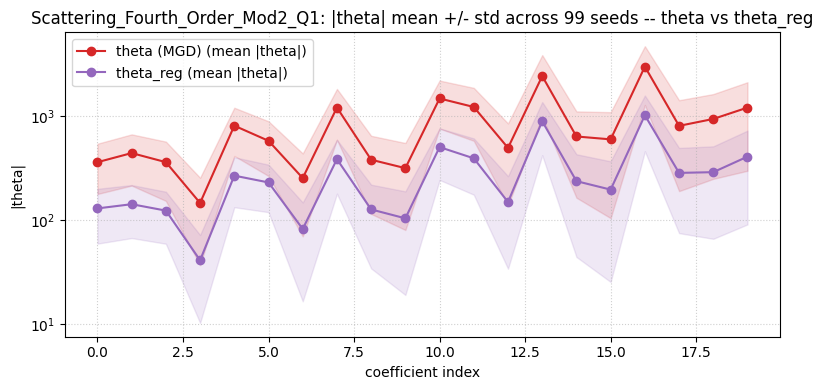

In [14]:
def plot_linear_potential_compare(sources, potentials, target_key, known_dims=None, yscale='symlog'):
    """Overlay mean +/- std across seeds for target_key from multiple theta
    sources (e.g. theta vs theta_reg) in ONE figure, so they're directly
    comparable and unambiguously labeled by source name (not two figures
    with the same title)."""
    col_map = None
    plt.figure(figsize=(8, 4))
    for (name, theta_arr), color in zip(sources.items(), ['tab:blue', 'tab:orange', 'tab:green']):
        theta_np = theta_arr.detach().cpu().numpy() if torch.is_tensor(theta_arr) else np.asarray(theta_arr)
        if col_map is None:
            col_map = theta_column_map(potentials, theta_np.shape[-1], known_dims=known_dims, verbose=False)
        start, dim = col_map[target_key]
        theta_slice = theta_np[:, start:start + dim]
        mean, std = theta_slice.mean(axis=0), theta_slice.std(axis=0)
        x = np.arange(dim)
        plt.plot(x, mean, marker='o', color=color, label=f'{name} (mean)')
        plt.fill_between(x, mean - std, mean + std, alpha=0.15, color=color)
    if yscale != 'linear':
        plt.yscale(yscale)
    plt.title(f'{target_key}: mean +/- std across {theta_all.shape[0]} seeds -- theta vs theta_reg')
    plt.xlabel('coefficient index')
    plt.ylabel('theta')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


def plot_complex_potential_compare(sources, potentials, real_key, imag_key,
                                    combined_name=None, index_convention='mod2', yscale='symlog'):
    """Overlay |theta_complex| mean +/- std across seeds for the Real/Imag
    pair from multiple theta sources (e.g. theta vs theta_reg) in ONE figure."""
    combined_name = combined_name or f"{real_key} + i*{imag_key}"
    col_map = None
    plt.figure(figsize=(8, 4))
    for (name, theta_arr), color in zip(sources.items(), ['tab:red', 'tab:purple', 'tab:green']):
        theta_np = theta_arr.detach().cpu().numpy() if torch.is_tensor(theta_arr) else np.asarray(theta_arr)
        if col_map is None:
            col_map = theta_column_map(potentials, theta_np.shape[-1], verbose=False)
        start_re, dim_re = col_map[real_key]
        start_im, dim_im = col_map[imag_key]
        theta_re_all = theta_np[:, start_re:start_re + dim_re]
        theta_im_all = theta_np[:, start_im:start_im + dim_im]
        pot_re, pot_im = potentials[real_key], potentials[imag_key]
        if hasattr(pot_re, 'indices') and hasattr(pot_im, 'indices'):
            theta_im_expanded = expand_imag_to_real_indices(
                pot_im, pot_re, theta_im_all, index_convention=index_convention,
            )
        else:
            assert theta_re_all.shape == theta_im_all.shape, (
                f"'{real_key}'/'{imag_key}' shape mismatch and no .indices to align on."
            )
            theta_im_expanded = theta_im_all
        theta_complex_all = theta_re_all + 1j * theta_im_expanded
        mag = np.abs(theta_complex_all)
        mean, std = mag.mean(axis=0), mag.std(axis=0)
        x = np.arange(dim_re)
        plt.plot(x, mean, marker='o', color=color, label=f'{name} (mean |theta|)')
        plt.fill_between(x, np.clip(mean - std, 0, None), mean + std, alpha=0.15, color=color)
    if yscale != 'linear':
        plt.yscale(yscale)
    plt.title(f'{combined_name}: |theta| mean +/- std across {theta_all.shape[0]} seeds -- theta vs theta_reg')
    plt.xlabel('coefficient index')
    plt.ylabel('|theta|')
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()


#plot_linear_potential_compare(SOURCES, potentials, 'Scattering_First_Order')
plot_linear_potential_compare(SOURCES, potentials, 'Scattering_Second_Order')
plot_complex_potential_compare(SOURCES, potentials, REAL_KEY, IMAG_KEY, combined_name=COMPLEX_NAME)


## 6. Normalization — theta vs theta_reg, mean +/- std across seeds

Same physical-normalization conventions as before
(`build_theta_dataframe`/`build_complex_theta_dataframe`, `normalize_by`
in `{'raw', 'm_k', 'std_k'}`), run once per seed **per source**
(`theta_all` and `theta_reg_all` separately) — using that seed's own
`mk_all[i]`/`stdk_all[i]` (shared between both sources, since `m_k`/`std_k`
only depend on `x1` and `potentials`, not on which theta) — then collapsed
across seeds with `aggregate_over_seeds` into a per-coefficient mean +/-
std. `dfs_by_source['theta (MGD)']` / `dfs_by_source['theta_reg']` hold the
two sources' results side by side; every print/plot below is explicitly
labeled by source. The `scale_gap` diagnostic groups by fine-scale
separation `|s1-s2|` on the seed-averaged values, same as before, printed
once per source per normalization convention.


In [15]:
def aggregate_over_seeds(dfs_per_seed):
    """Concat per-seed tidy dataframes (same potential/coefficient layout, one
    row per coefficient per seed) and collapse the seed axis into standardized
    value_mean/value_std/norm_mean/norm_std columns. Uses np.mean/np.std (not
    pandas' own .mean()/.std()) so the complex-valued 'theta_complex' column
    is handled correctly -- std of a complex array here is the real,
    non-negative sqrt(mean(|x - mean(x)|^2))."""
    combined = pd.concat(dfs_per_seed, ignore_index=True)
    value_col = 'theta_complex' if 'theta_complex' in combined.columns else 'theta_t1'
    norm_col = value_col + '_normalized'
    index_cols = [c for c in ('potential', 'coeff_idx', 'j', 'k_prime', 'k') if c in combined.columns]

    rows = []
    for key, group in combined.groupby(index_cols, sort=False):
        key = key if isinstance(key, tuple) else (key,)
        row = dict(zip(index_cols, key))
        raw_vals, norm_vals = group[value_col].to_numpy(), group[norm_col].to_numpy()
        row['value_mean'] = np.mean(raw_vals)
        row['value_std'] = np.std(raw_vals)
        row['norm_mean'] = np.nanmean(norm_vals)
        row['norm_std'] = np.nanstd(norm_vals)
        rows.append(row)
    return pd.DataFrame(rows)


def build_seed_averaged_dfs(theta_source, norm_name, norm_kwargs_base):
    dfs_n = {}
    for key in terms:
        if key in (REAL_KEY, IMAG_KEY):
            continue
        per_seed_dfs = []
        for i, seed in enumerate(seeds_loaded):
            kw = dict(norm_kwargs_base)
            if norm_name == 'm_k':
                kw['m_k'] = mk_all[i]
            elif norm_name == 'std_k':
                kw['std_k'] = stdk_all[i]
            df = build_theta_dataframe(theta_source[i], potentials, key, x1=x1_last, filters=filters, **kw)
            df['seed'] = seed
            per_seed_dfs.append(df)
        dfs_n[key] = aggregate_over_seeds(per_seed_dfs)

    if REAL_KEY in terms and IMAG_KEY in terms:
        per_seed_dfs = []
        for i, seed in enumerate(seeds_loaded):
            kw = dict(norm_kwargs_base)
            if norm_name == 'm_k':
                kw['m_k'] = mk_all[i]
            elif norm_name == 'std_k':
                kw['std_k'] = stdk_all[i]
            df = build_complex_theta_dataframe(
                theta_source[i], potentials, REAL_KEY, IMAG_KEY, x1=x1_last, filters=filters,
                combined_name=COMPLEX_NAME, **kw,
            )
            df['seed'] = seed
            per_seed_dfs.append(df)
        dfs_n[COMPLEX_NAME] = aggregate_over_seeds(per_seed_dfs)

    return dfs_n


NORMALIZATIONS = {
    'raw':   dict(normalize_by='raw'),
    'm_k':   dict(normalize_by='m_k'),
    'std_k': dict(normalize_by='std_k'),
}

# dfs_by_source[source_name][norm_name][potential_key] -> seed-aggregated df
dfs_by_source = {
    src_name: {norm_name: build_seed_averaged_dfs(src_arr, norm_name, kw) for norm_name, kw in NORMALIZATIONS.items()}
    for src_name, src_arr in SOURCES.items()
}
dfs = dfs_by_source['theta (MGD)']['raw']  # kept so any later cell that still expects `dfs` keeps working

for src_name, dfs_by_norm in dfs_by_source.items():
    print(f"\n{'=' * 20} {src_name} {'=' * 20}")
    reference_dfs = dfs_by_norm['raw']
    print(f"Raw |theta| mean +/- std across {len(seeds_loaded)} seeds (same for every convention):")
    for key, df in reference_dfs.items():
        mean_abs, std_abs = df['value_mean'].abs(), df['value_std'].abs()
        print(f"  {key:40s}  mean={mean_abs.mean():.3e} +/- {std_abs.mean():.3e}  max={mean_abs.max():.3e}")

    for norm_name, dfs_n in dfs_by_norm.items():
        print(f"\nNormalized |theta| via normalize_by='{norm_name}' (mean +/- std across seeds):")
        for key, df in dfs_n.items():
            mean_abs, std_abs = df['norm_mean'].abs(), df['norm_std'].abs()
            print(f"  {key:40s}  mean={mean_abs.mean():.3e} +/- {std_abs.mean():.3e}  max={mean_abs.max():.3e}")

    for norm_name, dfs_n in dfs_by_norm.items():
        if COMPLEX_NAME not in dfs_n:
            continue
        df_scat = dfs_n[COMPLEX_NAME].copy()
        df_scat['scale_gap'] = (df_scat['k_prime'] - df_scat['k']).abs()
        gap_summary = (
            df_scat.assign(abs_norm=df_scat['norm_mean'].abs(), abs_norm_std=df_scat['norm_std'].abs())
            .groupby('scale_gap')
            .agg(mean_of_seed_means=('abs_norm', 'mean'), max_of_seed_means=('abs_norm', 'max'),
                 mean_seed_std=('abs_norm_std', 'mean'), count=('abs_norm', 'count'))
        )
        print(f"\n{COMPLEX_NAME} ({src_name}, {norm_name}): |theta_normalized| seed-mean by fine-scale separation |s1-s2|")
        print(gap_summary)



==================== theta (MGD) ====================
Raw |theta| mean +/- std across 99 seeds (same for every convention):
  Scattering_Second_Order                   mean=3.106e+01 +/- 1.157e+02  max=6.170e+01
  Scattering_Fourth_Order_Mod2_Q1           mean=9.790e+01 +/- 1.029e+03  max=7.149e+02

Normalized |theta| via normalize_by='raw' (mean +/- std across seeds):
  Scattering_Second_Order                   mean=3.106e+01 +/- 1.157e+02  max=6.170e+01
  Scattering_Fourth_Order_Mod2_Q1           mean=9.790e+01 +/- 1.029e+03  max=7.149e+02

Normalized |theta| via normalize_by='m_k' (mean +/- std across seeds):
  Scattering_Second_Order                   mean=3.141e+00 +/- 9.771e+00  max=7.521e+00
  Scattering_Fourth_Order_Mod2_Q1           mean=3.419e-01 +/- 3.271e+00  max=1.739e+00

Normalized |theta| via normalize_by='std_k' (mean +/- std across seeds):
  Scattering_Second_Order                   mean=1.533e+00 +/- 5.205e+00  max=2.705e+00
  Scattering_Fourth_Order_Mod2_Q1        

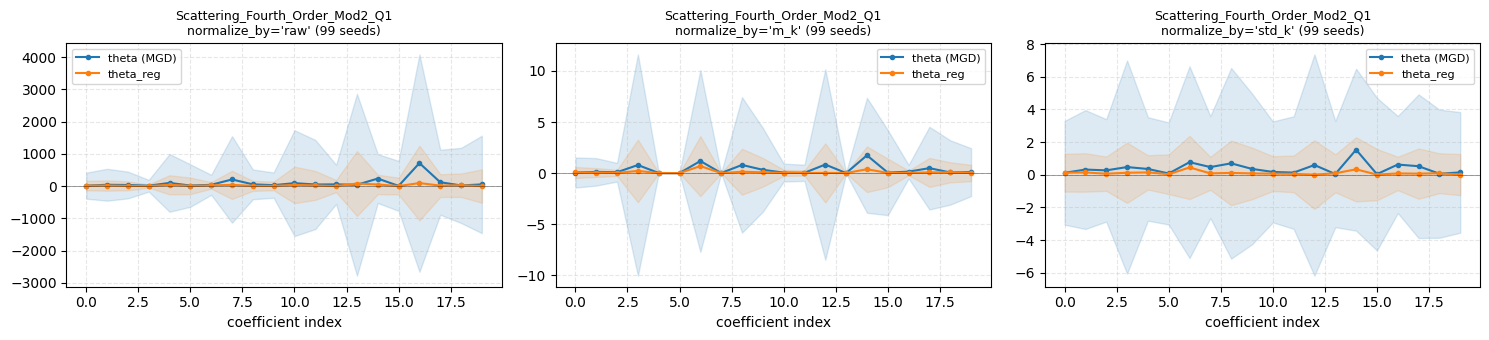

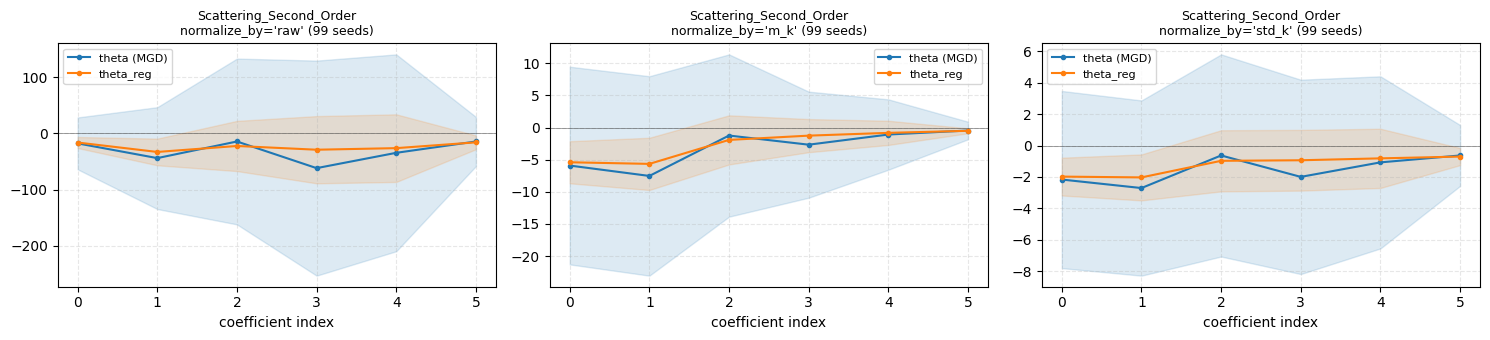

In [16]:
%matplotlib inline

def plot_normalization_comparison(dfs_by_source, key):
    norm_names = list(next(iter(dfs_by_source.values())).keys())
    colors = dict(zip(dfs_by_source.keys(), ['tab:blue', 'tab:orange', 'tab:green']))
    fig, axes = plt.subplots(1, len(norm_names), figsize=(5 * len(norm_names), 3.5), squeeze=False)
    axes = axes[0]
    for ax, norm_name in zip(axes, norm_names):
        for src_name, dfs_by_norm in dfs_by_source.items():
            df = dfs_by_norm[norm_name][key]
            mean, std = df['norm_mean'].to_numpy(), df['norm_std'].to_numpy()
            if np.iscomplexobj(mean):
                mean, std = np.abs(mean), np.abs(std)
            ax.plot(df['coeff_idx'], mean, 'o-', ms=3, color=colors[src_name], label=src_name)
            ax.fill_between(df['coeff_idx'], mean - std, mean + std, alpha=0.15, color=colors[src_name])
        ax.axhline(0, color='black', lw=0.5, alpha=0.5)
        ax.set_title(f"{key}\nnormalize_by='{norm_name}' ({len(seeds_loaded)} seeds)", fontsize=9)
        ax.set_xlabel('coefficient index')
        ax.legend(fontsize=8)
        ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

if COMPLEX_NAME in dfs:
    plot_normalization_comparison(dfs_by_source, COMPLEX_NAME)

for key in dfs:
    if key == COMPLEX_NAME:
        continue
    plot_normalization_comparison(dfs_by_source, key)


mean |theta_normalized| (averaged over coefficients AND seeds), by source:
                                                   raw       m_k     std_k
source      potential                                                     
theta (MGD) Scattering_Second_Order          31.064133  3.140568  1.532966
            Scattering_Fourth_Order_Mod2_Q1  97.895279  0.341854  0.392965
theta_reg   Scattering_Second_Order          23.727112  2.585653  1.238650
            Scattering_Fourth_Order_Mod2_Q1  25.893621  0.092460  0.112588

companion std (averaged over coefficients, of the per-coefficient across-seed std), by source:
                                                     raw       m_k     std_k
source      potential                                                       
theta (MGD) Scattering_Second_Order           115.662689  9.771243  5.205453
            Scattering_Fourth_Order_Mod2_Q1  1029.324585  3.270598  4.169508
theta_reg   Scattering_Second_Order            35.053997  2.668590  1.4

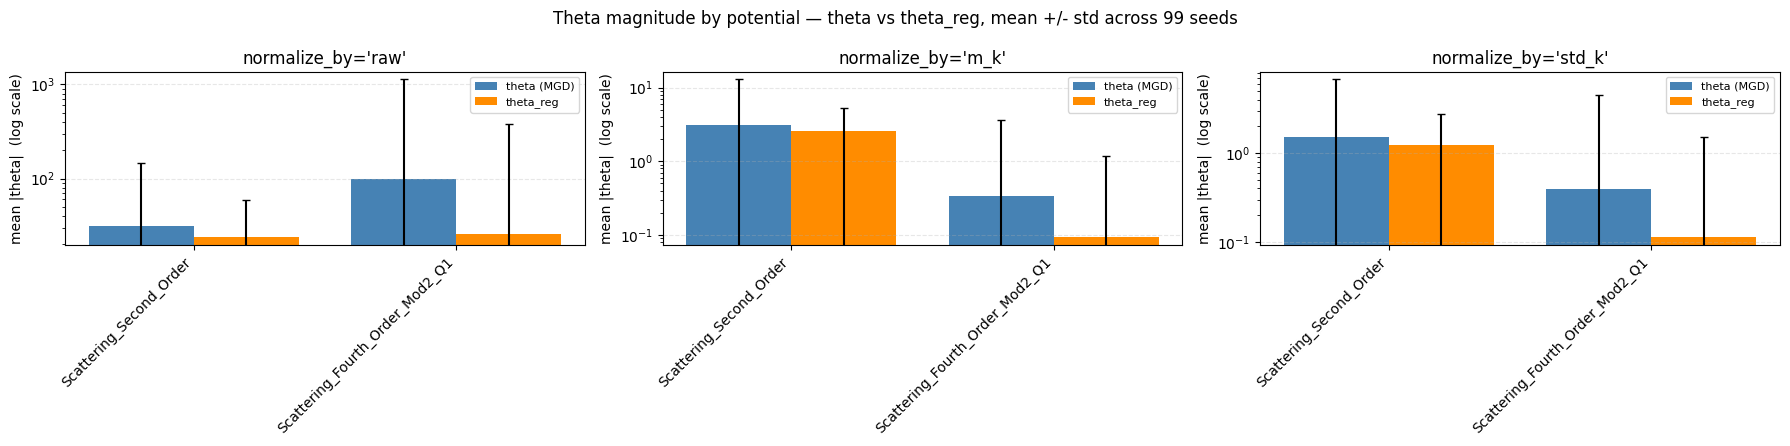


[theta (MGD)] Scattering_Fourth_Order_Mod2_Q1 mean|theta|  /  mean over other potentials' mean|theta|:
  raw     : 3.15x
  m_k     : 0.11x
  std_k   : 0.26x

[theta_reg] Scattering_Fourth_Order_Mod2_Q1 mean|theta|  /  mean over other potentials' mean|theta|:
  raw     : 1.09x
  m_k     : 0.04x
  std_k   : 0.09x


In [17]:
summary_rows, summary_std_rows = [], []
for src_name, dfs_by_norm in dfs_by_source.items():
    for key in dfs_by_norm['raw']:
        row, row_std = {'source': src_name, 'potential': key}, {'source': src_name, 'potential': key}
        for norm_name, dfs_n in dfs_by_norm.items():
            df = dfs_n[key]
            row[norm_name] = df['norm_mean'].abs().mean()
            row_std[norm_name] = df['norm_std'].abs().mean()
        summary_rows.append(row)
        summary_std_rows.append(row_std)

summary_df = pd.DataFrame(summary_rows).set_index(['source', 'potential'])
summary_std_df = pd.DataFrame(summary_std_rows).set_index(['source', 'potential'])
print("mean |theta_normalized| (averaged over coefficients AND seeds), by source:")
print(summary_df.round(6))
print("\ncompanion std (averaged over coefficients, of the per-coefficient across-seed std), by source:")
print(summary_std_df.round(6))

active = list(NORMALIZATIONS.keys())
src_names = list(dfs_by_source.keys())
potentials_order = list(dfs_by_source[src_names[0]]['raw'].keys())
colors = dict(zip(src_names, ['steelblue', 'darkorange', 'seagreen']))
x = np.arange(len(potentials_order))
width = 0.8 / len(src_names)

fig, axes = plt.subplots(1, len(active), figsize=(6 * len(active), 4.5), squeeze=False)
axes = axes[0]
for ax, norm_name in zip(axes, active):
    for j, src_name in enumerate(src_names):
        means = [summary_df.loc[(src_name, p), norm_name] for p in potentials_order]
        stds = [summary_std_df.loc[(src_name, p), norm_name] for p in potentials_order]
        offset = (j - (len(src_names) - 1) / 2) * width
        ax.bar(x + offset, means, width=width, yerr=stds, color=colors[src_name],
               label=src_name, capsize=3)
    ax.set_yscale('log')
    ax.set_xticks(x)
    ax.set_xticklabels(potentials_order, rotation=45, ha='right')
    ax.set_ylabel('mean |theta|  (log scale)')
    ax.set_title(f"normalize_by='{norm_name}'")
    ax.legend(fontsize=8)
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
fig.suptitle(f'Theta magnitude by potential — theta vs theta_reg, mean +/- std across {len(seeds_loaded)} seeds')
fig.tight_layout()
plt.show()

for src_name in src_names:
    if COMPLEX_NAME not in potentials_order:
        continue
    others = summary_df.loc[src_name].drop(index=COMPLEX_NAME)
    print(f"\n[{src_name}] {COMPLEX_NAME} mean|theta|  /  mean over other potentials' mean|theta|:")
    for norm_name in active:
        ratio = summary_df.loc[(src_name, COMPLEX_NAME), norm_name] / others[norm_name].mean()
        print(f"  {norm_name:8s}: {ratio:.2f}x")


## Energy per component 

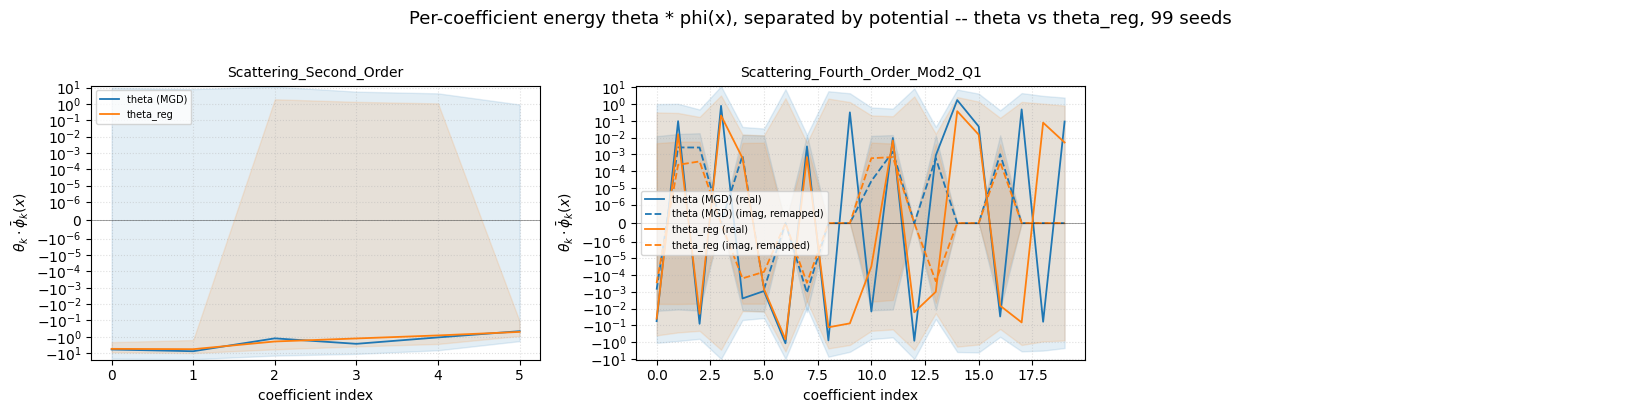

In [18]:
%matplotlib inline
import math  # skip if already imported

theta_np_all = theta_all.detach().cpu().numpy() if torch.is_tensor(theta_all) else np.asarray(theta_all)
theta_reg_np_all = theta_reg_all.detach().cpu().numpy() if torch.is_tensor(theta_reg_all) else np.asarray(theta_reg_all)

# energy[i, k] = theta_k * E_x1[phi_k(x1)] for seed i, coefficient k -- the actual
# per-coefficient term in theta . phi(x), NOT a rescaling of theta.
energy_by_source = {
    'theta (MGD)': theta_np_all * mk_all,
    'theta_reg':   theta_reg_np_all * mk_all,
}
source_colors = {'theta (MGD)': 'tab:blue', 'theta_reg': 'tab:orange'}

col_map = theta_column_map(potentials, theta_np_all.shape[-1], verbose=False)

def plot_energy_canvas(ax, title, series_by_source):
    """series_by_source: {src_name: [(label, x, mean, std, linestyle), ...]}"""
    for src_name, series_list in series_by_source.items():
        color = source_colors[src_name]
        for label, x, mean, std, ls in series_list:
            leg = f'{src_name} ({label})' if label else src_name
            ax.plot(x, mean, color=color, lw=1.3, ls=ls, label=leg)
            ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.12)
    ax.axhline(0, color='black', lw=0.5, alpha=0.5)
    ax.set_yscale('symlog', linthresh=1e-6)
    ax.set_xlabel('coefficient index')
    ax.set_ylabel(r'$\theta_k \cdot \bar\phi_k(x)$')
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle=':', alpha=0.4)

complex_pairs = {COMPLEX_NAME: (REAL_KEY, IMAG_KEY)}   # extend here if more Real/Imag pairs exist
handled = set(REAL_KEY) | set(IMAG_KEY) if False else {REAL_KEY, IMAG_KEY}
simple_keys = [k for k in col_map if k not in handled]

n_panels = len(simple_keys) + sum(1 for _, (rk, ik) in complex_pairs.items() if rk in col_map and ik in col_map)
ncols = 3
nrows = math.ceil(n_panels / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5.5 * ncols, 4 * nrows), squeeze=False)
axes = axes.flatten()
panel_i = 0

# --- simple (real-valued) potentials: MGD vs REG, one solid line each ---
for key in simple_keys:
    start, dim = col_map[key]
    x = np.arange(dim)
    series_by_source = {}
    for src_name, energy_arr in energy_by_source.items():
        e_slice = energy_arr[:, start:start + dim]
        mean, std = e_slice.mean(axis=0), e_slice.std(axis=0, ddof=1)
        series_by_source[src_name] = [(None, x, mean, std, '-')]
    plot_energy_canvas(axes[panel_i], key, series_by_source)
    panel_i += 1

# --- Real/Imag pairs: remap imaginary energy onto the real coefficient layout,
# then plot both on the SAME axis -- real=solid, imag=dashed, color=source ---
for combined_name, (real_key, imag_key) in complex_pairs.items():
    if real_key not in col_map or imag_key not in col_map:
        continue
    start_re, dim_re = col_map[real_key]
    start_im, dim_im = col_map[imag_key]
    pot_re, pot_im = potentials[real_key], potentials[imag_key]
    x = np.arange(dim_re)
    series_by_source = {}
    for src_name, energy_arr in energy_by_source.items():
        e_re_all = energy_arr[:, start_re:start_re + dim_re]         # (n_seeds, dim_re)
        e_im_native_all = energy_arr[:, start_im:start_im + dim_im]  # (n_seeds, dim_im)
        e_im_remapped_all = expand_imag_to_real_indices(pot_im, pot_re, e_im_native_all, index_convention='mod2')
        mean_re, std_re = e_re_all.mean(axis=0), e_re_all.std(axis=0, ddof=1)
        mean_im, std_im = e_im_remapped_all.mean(axis=0), e_im_remapped_all.std(axis=0, ddof=1)
        series_by_source[src_name] = [
            ('real', x, mean_re, std_re, '-'),
            ('imag, remapped', x, mean_im, std_im, '--'),
        ]
    plot_energy_canvas(axes[panel_i], combined_name, series_by_source)
    panel_i += 1

for j in range(panel_i, len(axes)):
    axes[j].axis('off')

fig.suptitle(f'Per-coefficient energy theta * phi(x), separated by potential -- theta vs theta_reg, '
             f'{len(seeds_loaded)} seeds', fontsize=13, y=1.02)
fig.tight_layout()
plt.show()


## Next steps

Natural refinements from here:
- Break the scattering theta down `|theta|` vs `k` (per `j`) and vs `j`
  (per `k`), the way `turb_theta_scaling.ipynb`'s
  `plot_modulus_vs_k_grid` / `plot_modulus_vs_j_grid` do, to see the
  near-diagonal-vs-far-diagonal decay shape directly instead of via the
  `scale_gap` groupby above.
- Compute the *analytic* Gaussian baseline for `H != 0.5` runs (from the fGn
  power spectrum and the filter bank's transfer functions) and compare
  against that instead of literal zero -- needed as soon as `--hurst` moves
  away from 0.5, per the intro markdown.
- Compare across `--intermittency` values (0 = Gaussian vs. >0 =
  multifractal) to see the far-diagonal thetas grow away from the Gaussian
  floor as the data becomes genuinely non-Gaussian.
- Compare the `nt=500` and `nt=600` seed-sweep families (and the
  `order_1_and_2`-only term set, hash `ed1bd1e1`) against this one --
  section 1's `terms`/`nt`/`lam` select which of the four synced families
  loads.
